# Assignment 2. Sensitivity Analysis: Which Inputs Matter?

**Course:** EPA141A Model Based Decision Making — Delft University of Technology  
**Model:** JUSTICE 

---

## Learning Outcomes

After completing this assignment you will be able to:
1. Explain the purpose of sensitivity analysis and when to apply it.
2. Compute **Extra-Trees feature importance** using the EMA Workbench `feature_scoring` module.
3. Run a **Morris elementary effects** analysis with SALib and interpret **μ\*** and **σ**.
4. Compare sensitivity rankings under **no abatement** vs. **moderate abatement** and explain
   what policy-conditional sensitivity means for decision-making.


---

## Background

Assignment 1 showed that four uncertain parameters produce a wide spread in all four outcomes.
Sensitivity analysis (SA) answers the follow-up question: **which inputs are responsible for that spread?**

Knowing this helps to:
- Prioritise where to invest in further research (reduce the most influential uncertainties first).
- Identify parameters that can safely be fixed without losing model fidelity.
- Understand whether the dominant driver of variability. 

We use two complementary methods that together give a complete picture:

**Extra-Trees feature importance** (EMA Workbench `feature_scoring`)  
Fits an ensemble of extremely randomised regression trees on the LHS ensemble from Step 2.
Reports how much each parameter reduces prediction variance across all trees. Fast, non-parametric,
and captures non-linear effects including `ecs_ensemble` (a discrete non-monotonic index).

**Morris elementary effects** (SALib `morris`)  
Perturbs each input one at a time from many random starting points and records the resulting
output change. Computes μ\* (mean absolute effect — importance) and σ (standard deviation —
non-linearity / interaction proxy). Morris handles non-monotonic and sign-changing model
responses reliably, making it the appropriate complement to ET for JUSTICE's welfare function.


## Setup — Imports and model configuration

The cell below imports all required packages (including SALib for Morris and EMA Workbench for Extra-Trees), configures logging, and defines the shared name lists for outcomes, parameters, and policies used throughout the analysis.

In [2]:
import os, sys
# ── Add JUSTICE-main to sys.path so justice internal imports resolve ───────────
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath('.')
_justice_root = os.path.normpath(os.path.join(_NOTEBOOK_DIR, '../JUSTICE-main'))

_PLOTS_DIR = os.path.join(_NOTEBOOK_DIR, "plots")
os.makedirs(_PLOTS_DIR, exist_ok=True)
if _justice_root not in sys.path:
    sys.path.insert(0, _justice_root)
os.chdir(_justice_root)

import warnings; warnings.filterwarnings("ignore")
import os
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from SALib.sample import morris as morris_sample
from SALib.analyze import morris as morris_analyze
from ema_workbench import (
    Model, RealParameter, ScalarOutcome, ArrayOutcome,
    perform_experiments, ema_logging, Sample,
    SequentialEvaluator,
)
from ema_workbench.em_framework.evaluators import Samplers
from ema_workbench.analysis import feature_scoring
from justice.model import JUSTICE
from justice.util.enumerations import WelfareFunction
from justice.objectives.objective_functions import years_above_temperature_threshold

ema_logging.log_to_stderr(logging.WARNING)

OBJECTIVES   = ["welfare", "years_above_temperature_threshold",
                "welfare_loss_damage", "welfare_loss_abatement"]
PARAMS       = ["rho", "eta", "delta", "ecs_ensemble"]
PARAMS_NORM  = ["rho", "eta", "delta"]
POLICY_NAMES = ["no_abatement", "moderate_abatement"]
palette      = {"no_abatement": "steelblue", "moderate_abatement": "darkorange"}

print("Imports OK")
import matplotlib.path as _mpath
def _patched_path_deepcopy(self, memo=None):
    if memo is None: memo = {}
    new_path = _mpath.Path.__new__(_mpath.Path)
    memo[id(self)] = new_path
    verts = self._vertices.copy()
    codes = self._codes.copy() if self._codes is not None else None
    new_path.__init__(verts, codes,
                      _interpolation_steps=self._interpolation_steps, readonly=False)
    return new_path
_mpath.Path.__deepcopy__ = _patched_path_deepcopy

Imports OK


---

## Step 1 — Define the model

The model wrapper is identical to Assignment 1: four uncertain parameters plus the `ecr_plateau` lever.

**Task 1.1** — Complete `justice_model` so it:
1. Hard-resets JUSTICE and instantiates it with the given `ecs_ensemble` index.
2. Sets ρ and η on both `model.economy` and `model.welfare_function`.
3. Scales the three damage coefficients by δ.
4. Runs with a uniform ECR equal to `ecr_plateau` across all regions and returns all four scalar outcomes plus the global mean temperature trajectory.

**Task 1.2** — Run the smoke test below and confirm the four outcomes are positive and in plausible ranges.

In [3]:
def justice_model(rho=0.015, eta=1.45, delta=1.0, ecs_ensemble=1, ecr_plateau=0.0):
    """EMA Workbench function model — 4 uncertain parameters + ECR lever.

    Parameters
    ----------
    ecr_plateau : float
        Emission control rate applied uniformly across all regions and timesteps.
        0.0 = no abatement; 0.4 = 40% moderate abatement.
    """
    JUSTICE.hard_reset()
    ensemble_idx = int(np.round(np.clip(ecs_ensemble, 1, 1001)))
    model = JUSTICE(
        start_year=2015, end_year=2300, timestep=1,
        scenario=2, climate_ensembles=ensemble_idx, stochastic_run=False,
        social_welfare_function=WelfareFunction.UTILITARIAN,
    )
    model.economy.pure_rate_of_social_time_preference = float(rho)
    model.economy.elasticity_of_marginal_utility_of_consumption = float(eta)
    model.welfare_function.pure_rate_of_social_time_preference = float(rho)
    model.welfare_function.elasticity_of_marginal_utility_of_consumption = float(eta)
    model.damage_function.coefficient_a                  *= float(delta)
    model.damage_function.coefficient_b                  *= float(delta)
    model.damage_function.damage_gdp_ratio_with_gradient *= float(delta)

    ecr = np.full(model.emission_control_rate.shape[:2], float(ecr_plateau))
    model.run(emission_control_rate=ecr, endogenous_savings_rate=True)
    datasets = model.evaluate()

    welfare = float(np.abs(np.squeeze(datasets["welfare"])))
    yat     = float(np.squeeze(
        years_above_temperature_threshold(datasets["global_temperature"], 2.0)
    ))
    _, _, _, wl_dmg = model.welfare_function.calculate_welfare(
        datasets["damage_cost_per_capita"], welfare_loss=True)
    _, _, _, wl_abt = model.welfare_function.calculate_welfare(
        datasets["abatement_cost_per_capita"], welfare_loss=True)
    temp = np.squeeze(datasets["global_temperature"])
    if temp.ndim == 2:
        temp = temp.mean(axis=0)

    return {
        "welfare":                           welfare,
        "years_above_temperature_threshold": yat,
        "welfare_loss_damage":               float(np.abs(np.squeeze(wl_dmg))),
        "welfare_loss_abatement":            float(np.abs(np.squeeze(wl_abt))),
        "temperature_trajectory":            temp.astype(float),
    }

# Smoke test
test = justice_model()
for k, v in test.items():
    if isinstance(v, np.ndarray):
        print(f"  {k}: array shape {v.shape}, range [{v.min():.2f}, {v.max():.2f}]")
    else:
        print(f"  {k}: {v:.4f}")

  welfare: 103.7211
  years_above_temperature_threshold: 259.0000
  welfare_loss_damage: 3980.5410
  welfare_loss_abatement: 74364.1321
  temperature_trajectory: array shape (286,), range [1.20, 6.01]


## Step 2 — EMA model setup and LHS ensemble

**Task 2.1** — Wrap `justice_model` in a `Model` object with the same four uncertain
parameters and four scalar outcomes as Assignment 1.

**Task 2.2** — Run 100 LHS scenarios under each policy using `SequentialEvaluator`. This
ensemble is used as input to the Extra-Trees analysis in Step 3.

**Task 2.3** — How does the `welfare_loss_abatement` distribution compare between the
two policies? Explain the difference.

---

*Note: The outcome distributions for both policies are fully explored in **Assignment 1**
(Steps 3–4). The key finding there was that `years_above_temperature_threshold` shows the
clearest policy separation (~15 year shift), while `welfare` distributions overlap almost
entirely — policy signal is overwhelmed by parametric uncertainty. SA in this assignment
explains **why** those distributions are wide and which specific inputs drive the spread. You can re-run the cell below or use your outputs generated from Assignment #1.*

In [4]:
em_model = Model('JUSTICE', function=justice_model)

em_model.uncertainties = [
    RealParameter('rho',          0.001,    0.030),
    RealParameter('eta',          0.5,      1.5),
    RealParameter('delta',        0.5,      2.0),
    RealParameter('ecs_ensemble', 1,     1001),
]

em_model.levers = [
    RealParameter('ecr_plateau', 0.0, 1.0),
]

em_model.outcomes = [
    ScalarOutcome('welfare'),
    ScalarOutcome('years_above_temperature_threshold'),
    ScalarOutcome('welfare_loss_damage'),
    ScalarOutcome('welfare_loss_abatement'),
    ArrayOutcome('temperature_trajectory'),
]

policies = [
    Sample('no_abatement',       ecr_plateau=0.0),
    Sample('moderate_abatement', ecr_plateau=0.4),
]

with SequentialEvaluator(em_model) as evaluator:
    experiments, outcomes = evaluator.perform_experiments(scenarios=100, policies=policies)

df_results = pd.DataFrame({k: v for k, v in outcomes.items() if k != 'temperature_trajectory'})
df_results['policy'] = experiments['policy'].values

print(f"experiments shape : {experiments.shape}")
print(f"policy counts     :\n{df_results['policy'].value_counts()}")
display(df_results[OBJECTIVES].describe().round(4))

100%|████████████████████████████████████████| 200/200 [25:31<00:00,  7.66s/it]

experiments shape : (200, 8)
policy counts     :
policy
moderate_abatement    100
no_abatement          100
Name: count, dtype: int64


,welfare,years_above_temperature_threshold,welfare_loss_damage,welfare_loss_abatement
count,200.0000,200.0000,200.0000,200.0000
mean,5553.5546,236.1800,6107.8995,12589.2037
std,42703.1829,23.2257,42611.4971,52466.5010
min,55.3751,0.0000,17.1185,3.5514
25%,239.4081,226.7500,208.5562,66.1960
50%,422.6224,240.5000,922.6930,484.1251
75%,909.1950,250.2500,1693.5972,3875.8035
max,427814.7395,264.0000,427347.0846,426712.8422


## Step 3 — Extra-Trees feature importance

`feature_scoring.get_feature_scores_all(x, y)` fits an `ExtraTreesRegressor` for each
outcome on the LHS ensemble and returns a DataFrame of importances
(rows = parameters, columns = outcomes).

Running the analysis separately for each policy tests whether sensitivity is
**policy-conditional** — i.e., whether the same parameter matters equally under
both no abatement and moderate abatement.

**Task 3.1** — Compute Extra-Trees importances for each policy separately.

**Task 3.2** — Plot the importances as a 2×2 bar-chart grid for each policy (two grids total).

**Task 3.3** — Which parameter dominates `years_above_temperature_threshold`? 

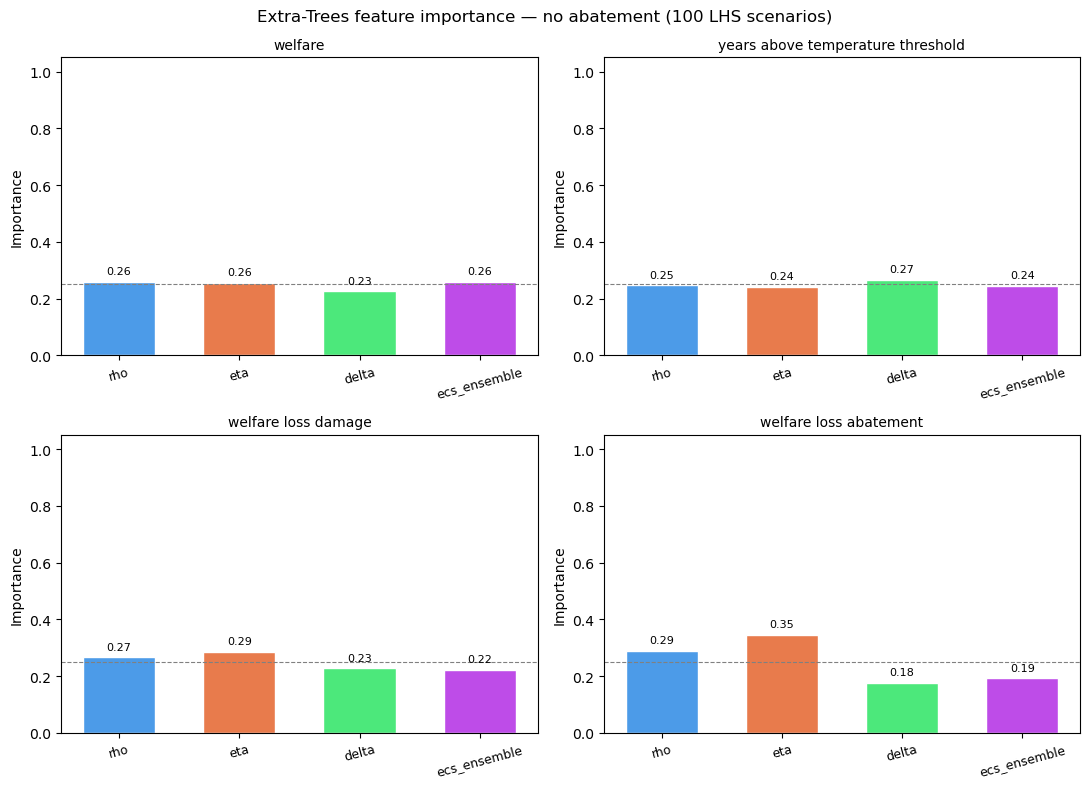

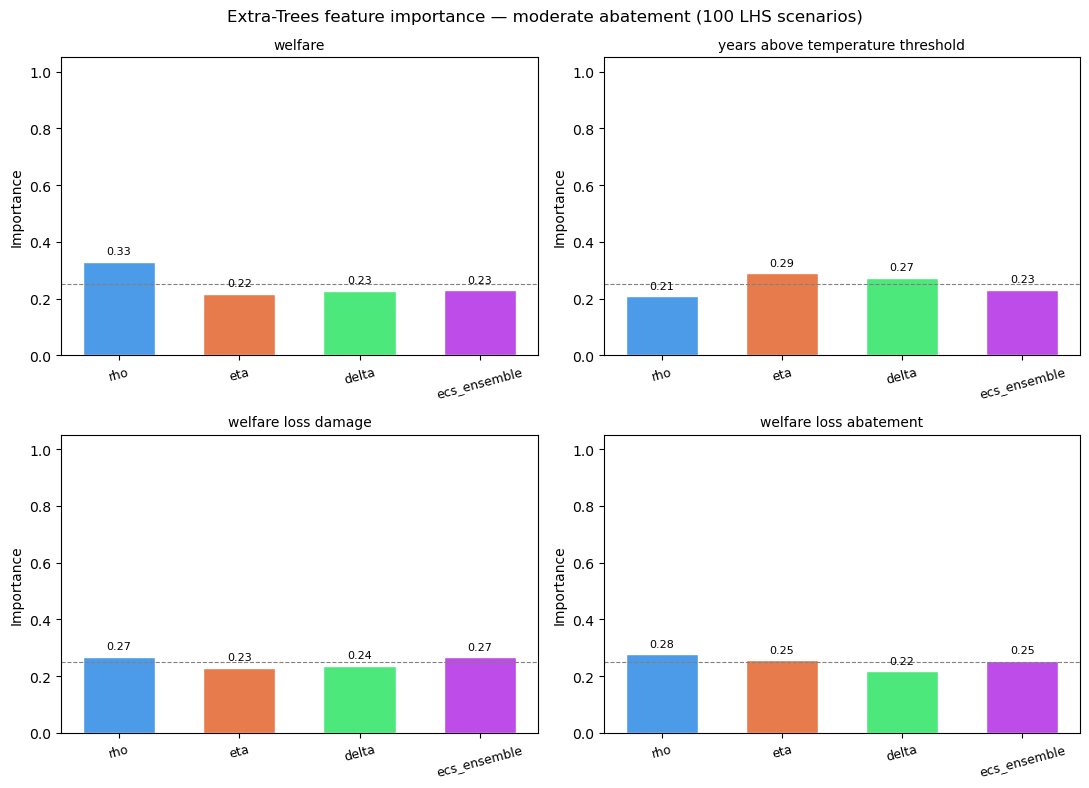

In [5]:
et_scores = {}
# for pol in POLICY_NAMES:
#     # Select only rows belonging to this policy
#     mask  = ___

#     # Build the input matrix: only the uncertain parameters, not the lever
#     x_pol = ___

#     # Build the output dict: filter each outcome array by the same mask
#     y_pol = {k: ___ for k in OBJECTIVES}

#     et_scores[pol] = feature_scoring.get_feature_scores_all(x_pol, y_pol)
#     print(f"\n--- {pol} ---")
#     print(et_scores[pol].round(3).to_string())
for pol in POLICY_NAMES:
    mask  = df_results['policy'] == pol
    x_pol = experiments.loc[mask, PARAMS]
    y_pol = {k: outcomes[k][mask] for k in OBJECTIVES}
    et_scores[pol] = feature_scoring.get_feature_scores_all(x_pol, y_pol)



colors = ['#4C9BE8', '#E87B4C', '#4CE87B', '#BE4CE8']
x = np.arange(len(PARAMS))

for pol in POLICY_NAMES:
    sc = et_scores[pol]
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    for ax, obj in zip(axes.flat, OBJECTIVES):
        imp  = sc[obj].reindex(PARAMS).values
        bars = ax.bar(x, imp, color=colors, edgecolor='white', width=0.6)
        ax.set_xticks(x); ax.set_xticklabels(PARAMS, rotation=15, fontsize=9)
        ax.set_ylim(0, 1.05); ax.set_title(obj.replace('_', ' '), fontsize=10)
        ax.set_ylabel('Importance'); ax.axhline(0.25, color='grey', lw=0.8, ls='--')
        for bar, val in zip(bars, imp):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    fig.suptitle(f"Extra-Trees feature importance — {pol.replace('_', ' ')} (100 LHS scenarios)",
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(_PLOTS_DIR, f"a02ema_et_{pol}.png"), dpi=150, bbox_inches='tight')
    plt.show()

## Step 4 — Policy-comparison sensitivity heatmap

A side-by-side heatmap (one panel per policy) puts both ET analyses on the same axes,
making it easy to see which parameters shift in importance between the two policies.
Importances are normalised per column so they sum to 1 within each outcome.

**Task 4.1** — Build the two normalised heatmaps and compare them.

**Task 4.2** — Which parameter gains the most importance under no abatement compared to
moderate abatement? Which loses importance? Explain both changes mechanistically.

**Task 4.3** — What does this imply for a decision-maker who needs to choose between the
two policies under deep uncertainty?

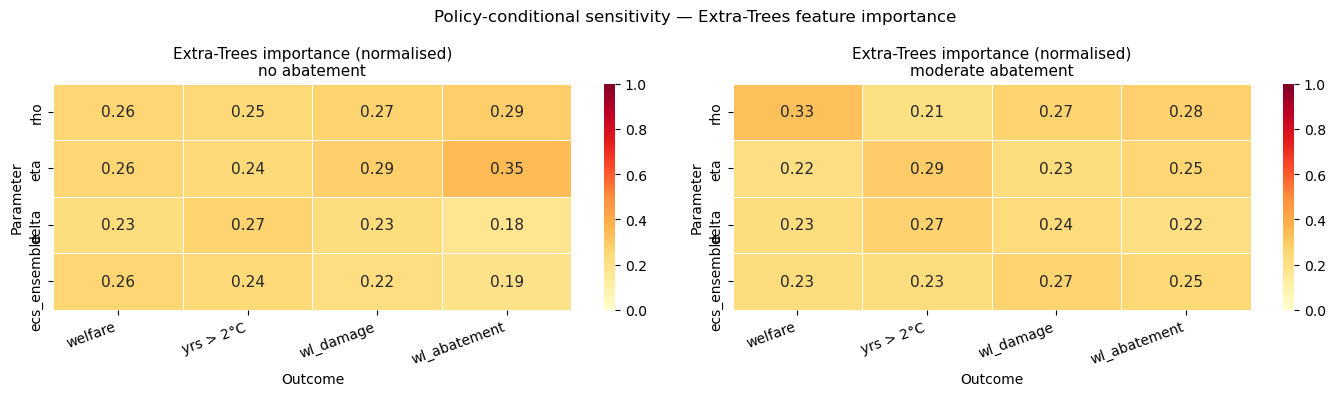


Change in normalised importance (no_abatement − moderate_abatement):
              welfare  years_above_temperature_threshold  welfare_loss_damage  welfare_loss_abatement
0                                                                                                    
rho            -0.071                              0.039               -0.001                   0.011
eta             0.040                             -0.047                0.056                   0.090
delta          -0.000                             -0.007               -0.010                  -0.041
ecs_ensemble    0.031                              0.014               -0.044                  -0.061


In [6]:
short = [o.replace('years_above_temperature_threshold', 'yrs > 2\u00b0C')
          .replace('welfare_loss_', 'wl_') for o in OBJECTIVES]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, pol in zip(axes, POLICY_NAMES):
    mat      = et_scores[pol].reindex(PARAMS)[OBJECTIVES]
    mat_norm = (mat / mat.sum()).fillna(0)
    sns.heatmap(mat_norm, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1,
                linewidths=0.5, ax=ax, annot_kws={'size': 11})
    ax.set_title(f'Extra-Trees importance (normalised)\n{pol.replace("_", " ")}',
                 fontsize=11)
    ax.set_xlabel('Outcome'); ax.set_ylabel('Parameter')
    ax.set_xticklabels(short, rotation=20, ha='right')

fig.suptitle("Policy-conditional sensitivity — Extra-Trees feature importance", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(_PLOTS_DIR, "a02ema_sensitivity_heatmap.png"), dpi=150, bbox_inches='tight')
plt.show()

mat_no  = (et_scores['no_abatement'].reindex(PARAMS)[OBJECTIVES] /
           et_scores['no_abatement'].reindex(PARAMS)[OBJECTIVES].sum()).fillna(0)
mat_mod = (et_scores['moderate_abatement'].reindex(PARAMS)[OBJECTIVES] /
           et_scores['moderate_abatement'].reindex(PARAMS)[OBJECTIVES].sum()).fillna(0)
diff = mat_no - mat_mod
print("\nChange in normalised importance (no_abatement \u2212 moderate_abatement):")
print(diff.round(3).to_string())

## Step 5. Morris elementary effects
The **Morris method** (elementary effects) is a global screening approach that perturbs one input at a time by a finite step and computes the resulting “elementary effect” on the output. For each input, it summarizes these effects by the mean of their absolute values, μ*, as a robust importance measure (always non-negative), and by their standard deviation, σ, as an indicator of non-linearity and interaction with other parameters.

In [8]:
from ema_workbench.em_framework.salib_samplers import MorrisSampler

#Before writing any code, answer the following:

# 1. Morris perturbs parameters one-at-a-time with finite differences. Why does this make `ecs_ensemble` unsuitable as a Morris input, even though it was useful in the Extra-Trees analysis?
# 2. If `ecs_ensemble` is excluded, should you remove it entirely or hold it fixed? What fixed value makes sense?
# 3. `MorrisSampler` generates an OAT design in unit space `[0, 1]` and the workbench rescales to actual bounds. When you later call `morris_analyze.analyze`, which bounds should the problem dict contain — unit bounds or actual bounds? Why?

# **Task 5.1 — Morris model wrapper**
ECS_MEDIAN = 501

def justice_model_morris(rho=0.015, eta=1.45, delta=1.0, ecr_plateau=0.0):
    return justice_model(rho=rho, eta=eta, delta=delta,
                         ecs_ensemble=ECS_MEDIAN, ecr_plateau=ecr_plateau)

em_model_morris = Model('JUSTICEmorris', function=justice_model_morris)
em_model_morris.uncertainties = [
    RealParameter('rho',   0.001, 0.030),
    RealParameter('eta',   0.5,   1.5),
    RealParameter('delta', 0.5,   2.0),
]
em_model_morris.levers   = em_model.levers
em_model_morris.outcomes = em_model.outcomes



# **Task 5.2 — SALib problem definition**

# Define the Morris problem dict. Parameter names must match the column names that `perform_experiments` returns. Bounds must be the actual parameter ranges so that `morris_analyze` scales elementary effects correctly.
# Code stub 5.2


morris_problem = {
    'num_vars': 3,
    'names':    ['rho', 'eta', 'delta'],
    'bounds':   [[0.001, 0.030],
                 [0.5,   1.5],
                 [0.5,   2.0]],
}


# **Task 5.3 — Run and analyse**

# Use `perform_experiments` with `MorrisSampler()` to generate the OAT design and run the model. Extract the X matrix and call `morris_analyze.analyze` once per outcome per policy. Store results in `morris_results[pol][outcome_name]`.
# Code stub 5.3


N_MORRIS = 50

morris_results = {}
for pol, ecr_val in [('no_abatement', 0.0), ('moderate_abatement', 0.4)]:
    with SequentialEvaluator(em_model_morris) as evaluator:
        exps_m, outs_m = evaluator.perform_experiments(
            scenarios=N_MORRIS,
            uncertainty_sampling=MorrisSampler(),
            policies=[Sample(pol, ecr_plateau=ecr_val)],
        )
    X = exps_m[['rho', 'eta', 'delta']].values
    morris_results[pol] = {
        obj: morris_analyze.analyze(morris_problem, X, outs_m[obj],
                                    print_to_console=False)
        for obj in OBJECTIVES
    }




# Summary tables — mu_star per policy
for pol in POLICY_NAMES:
    print(f"\n=== {pol} — μ* ===")
    rows = {p: [morris_results[pol][o]['mu_star'][i] for o in OBJECTIVES]
            for i, p in enumerate(MORRIS_PARAMS)}
    print(pd.DataFrame(rows, index=OBJECTIVES).T.round(2).to_string())


100%|████████████████████████████████████████| 200/200 [15:58<00:00,  4.79s/it]


=== no_abatement — μ* ===


NameError: name 'MORRIS_PARAMS' is not defined

In [ ]:
MORRIS_PARAMS = ['delta', 'eta', 'rho']   # alphabetical — matches morris_problem
x = np.arange(len(MORRIS_PARAMS))

for pol in POLICY_NAMES:
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    for ax, obj in zip(axes.flat, OBJECTIVES):
        Si = morris_results[pol][obj]
        mu_star = Si['mu_star']
        sigma   = Si['sigma']
        colors  = ['#4C9BE8', '#E87B4C', '#4CE87B']
        bars = ax.bar(x, mu_star, color=colors, edgecolor='white', width=0.5,
                      label='μ*')
        ax.scatter(x, sigma, color='black', zorder=5, s=40, marker='D',
                   label='σ (non-linearity)')
        for xi, (m, s) in enumerate(zip(mu_star, sigma)):
            ax.vlines(xi, m, s, colors='black', lw=1.5, linestyles='dashed')
        ax.set_xticks(x); ax.set_xticklabels(MORRIS_PARAMS, rotation=15)
        ax.set_title(obj.replace('_', ' '), fontsize=10)
        ax.set_ylabel('μ* / σ')
        ax.legend(fontsize=7)
        for bar, val in zip(bars, mu_star):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.01 * ax.get_ylim()[1],
                    f'{val:.0f}', ha='center', va='bottom', fontsize=7)
    fig.suptitle(
        f"Morris elementary effects — {pol.replace('_', ' ')}\n"
        f"3 normative parameters, N={N_MORRIS} (ecs_ensemble fixed at median)",
        fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(_PLOTS_DIR, f"a02ema_morris_{pol}.png"), dpi=150, bbox_inches='tight')
    display(fig)
    plt.close(fig)


## Reflection Questions

**1. What do ET and Morris together reveal** about
which type of uncertainty dominates each outcome?


**2. Policy-conditional sensitivity.** Which normative parameter's μ\* changed most
between the two policies? 

